<a href="https://colab.research.google.com/github/GaPau/MooCraDee/blob/add-colab-gpu-demo/pcs_gpu_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![PCS GPU Demo](https://raw.githubusercontent.com/GaPau/MooCraDee/add-colab-gpu-demo/assets/pcs_banner.png)](https://github.com/GaPau/MooCraDee)

# Planetary Crater Segmentation (PCS)

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/GaPau/MooCraDee/blob/add-colab-gpu-demo/notebooks/PCS_GPU_Demo.ipynb)
[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/GaPau/MooCraDee)
[![SAM](https://img.shields.io/badge/SAM-Segment%20Anything-orange)](https://github.com/facebookresearch/segment-anything)
[![arXiv](https://img.shields.io/badge/arXiv-2304.02643-b31b1b.svg)](https://arxiv.org/abs/2304.02643)

PCS is a GPU-enabled pipeline for detecting crater candidates in planetary images. Mercury is included as the default example, but users can upload images from other planetary bodies.

This notebook allows users to select an image, configure detection parameters, run the PCS pipeline, visualize the detected candidates, and export the results as a CSV file.

PCS is part of the MooCraDee project. It combines the Segment Anything Model (SAM) with computer vision and geometric filtering. SAM generates segmentation masks, and PCS filters them to identify structures with crater-like shapes.

The results are crater candidates and require further validation. This notebook is intended for reproducible testing, parameter analysis, and preparation of structured detection data.

# 1. How This Notebook Works

This notebook is designed as a guided pipeline. Each section explains what is happening, runs one part of the workflow, and prepares the next step.

By the end of the notebook, you will be able to:

* check that GPU acceleration is available,
* install the required dependencies,
* clone the PCS/MooCraDee repository,
* download the SAM model checkpoint,
* verify that the required files are available,
* run PCS on the default Mercury image or on your own uploaded planetary image,
* adjust detection parameters such as radius range, circularity, area, and SAM mask quality,
* visualize detected crater candidates,
* load the output CSV as a crater-candidate database,
* export results for future analysis.

**Pro Tip: Use GPU Acceleration**

PCS uses SAM, and SAM runs much faster with a GPU. In Google Colab, go to:

`Runtime` → `Change runtime type` → `Hardware accelerator` → `T4 GPU`

Then click `Save`.

**Where are the files saved?**

Google Colab runs in a temporary cloud environment. Files created during this session are saved under `/content/`. They are not automatically saved to Google Drive. If the runtime disconnects or restarts, the outputs may be deleted. At the end of this notebook, you will have the option to download the results or copy them to Google Drive.

Let's begin.


# 2. Runtime and GPU Setup

PCS uses the Segment Anything Model (SAM), which runs much faster with GPU acceleration. This section checks whether the current Colab runtime has access to a GPU.

If no GPU is detected, go to:

`Runtime` → `Change runtime type` → `Hardware accelerator` → `T4 GPU`

Then click `Save` and run this section again.


In [ ]:
import torch

if torch.cuda.is_available():
    print("GPU available:", torch.cuda.get_device_name(0))
else:
    print("GPU not available.")
    print("Go to Runtime > Change runtime type > Hardware accelerator > T4 GPU")

GPU available: Tesla T4


# 3. Install Dependencies

This section installs the Python libraries needed to run PCS.

PCS uses:

* **PyTorch** to run SAM with GPU support.
* **Segment Anything** to generate segmentation masks.
* **OpenCV** for image processing, contours, circularity filtering, and drawing detections.
* **Pillow** for image loading and splitting.
* **NumPy** for numerical operations.
* **Pandas** for loading and inspecting CSV outputs.
* **Matplotlib** for plots and result analysis.

The installation may take a few minutes the first time you run it.


In [ ]:
!pip install opencv-python pillow matplotlib numpy torch torchvision
!pip install git+https://github.com/facebookresearch/segment-anything.git

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-apr19ifj
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-apr19ifj
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=87822e12fe29ab0329e709e72a301fe95c9f10062be1b039c227ea6f519812e7
  Stored in directory: /tmp/pip-ephem-wheel-cache-knbsoi7h/wheels/29/82/ff/04e2be9805a1cb48bec0b85b5a6da6b63f647645750a0e42d4
Successfully built segment_anything


# 4. Clone Repository and Set Working Directory

This section downloads the PCS/MooCraDee project from GitHub into the Colab runtime.

The repository is saved inside Colab’s temporary file system, usually under `/content/MooCraDee`. This means the files are available while the current Colab session is active, but they are not automatically saved to Google Drive.

During development, this notebook may use a testing branch. After the Colab workflow is merged into the main project, the notebook should run from the `main` branch.



In [ ]:
from pathlib import Path

repo_url = "https://github.com/GaPau/MooCraDee.git"
repo_dir = Path("/content/MooCraDee")

branch_name = "add-colab-gpu-demo"  # CHANGEE to "main" after merging

if not repo_dir.exists():
    print("Cloning repository...")
    !git clone {repo_url} {repo_dir}
else:
    print("Repository already exists.")

%cd /content/MooCraDee

!git checkout {branch_name}

Cloning repository...
Cloning into '/content/MooCraDee'...
remote: Enumerating objects: 260, done.
remote: Counting objects: 100% (95/95), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 260 (delta 38), reused 1 (delta 1), pack-reused 165 (from 3)
Receiving objects: 100% (260/260), 521.94 MiB | 24.93 MiB/s, done.
Resolving deltas: 100% (65/65), done.
/content/MooCraDee
Branch 'add-colab-gpu-demo' set up to track remote branch 'add-colab-gpu-demo' from 'origin'.
Switched to a new branch 'add-colab-gpu-demo'


In [ ]:
!git checkout add-colab-gpu-demo

Already on 'add-colab-gpu-demo'
Your branch is up to date with 'origin/add-colab-gpu-demo'.


# 5. Download SAM Checkpoint

PCS uses the Segment Anything Model (SAM) from Meta AI. To run SAM, the notebook needs a model checkpoint file.

The checkpoint is not stored directly in the repository because model files can be large. Instead, this section downloads the SAM ViT-B checkpoint into the Colab runtime when needed.

If the checkpoint already exists, the notebook will skip the download.


In [ ]:
from pathlib import Path

checkpoint_path = Path("sam_vit_b_01ec64.pth")

if not checkpoint_path.exists():
    print("Downloading SAM ViT-B checkpoint...")
    !wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
    print("Download complete.")
else:
    print("SAM checkpoint already exists.")

Download complete.


# 6. Verify Required Files

Before running PCS, this section checks that the required project files are available in the Colab runtime.

PCS needs:

* `mercury.jpg` as the default Mercury test image,
* `run_pipeline.py` to run the full split-image workflow,
* `deep_moocrade.py` to run crater-candidate detection on one image,
* `split_image.py` to divide large images into smaller sections,
* `sam_vit_b_01ec64.pth` as the SAM model checkpoint.

If one of these files is missing, the notebook will show it here before the pipeline runs.


In [ ]:
from pathlib import Path

required_files = [
    "mercury.jpg",
    "run_pipeline.py",
    "deep_moocrade.py",
    "split_image.py",
    "sam_vit_b_01ec64.pth"
]

for file in required_files:
    if Path(file).exists():
        print(f"Found: {file}")
    else:
        print(f"Missing: {file}")

Found: mercury.jpg
Found: run_pipeline.py
Found: deep_moocrade.py
Found: split_image.py
Found: sam_vit_b_01ec64.pth


# 7. Select Input Image

PCS can run in two ways:

1. Use the default Mercury image included in the repository.
2. Upload your own planetary image from your computer.

For large planetary images, the split-image pipeline is recommended because it divides the image into smaller parts before detection. For smaller test images, the single-image mode can run directly without splitting.

Supported image formats include `.jpg`, and `.png`.



In [ ]:
from google.colab import files
from pathlib import Path

use_uploaded_image = True  # Change to True if you want to upload your own image

if use_uploaded_image:
    uploaded = files.upload()
    image_path = list(uploaded.keys())[0]
    print("Uploaded image:", image_path)
else:
    image_path = "mercury.jpg"
    print("Using default image:", image_path)

image_path = Path(image_path)

Saving Benchmark 01.png to Benchmark 01.png
Uploaded image: Benchmark 01.png


# 8. Configure Detection Parameters

This section controls how PCS filters crater candidates.

SAM generates segmentation masks, but not every mask is a crater. PCS uses geometric and filters to keep masks that look more crater-like.

You can adjust these values to test how the results change:

* `min_radius`: smallest crater candidate radius allowed, in pixels.
* `max_radius`: largest crater candidate radius allowed, in pixels.
* `min_circularity`: how circular a candidate must be. Higher values are stricter.
* `min_area`: removes masks that are too small.
* `points_per_side`: controls how densely SAM samples the image. Higher values may detect more masks, but can be slower.
* `pred_iou`: SAM’s predicted mask quality threshold.
* `stability`: how stable the SAM mask must be.
* `iou_dedup`: removes duplicate crater candidates that overlap too much.

Start with the default values below. Then try changing one parameter at a time to see how the detection results change.


In [ ]:
# BASE
min_radius = 20
max_radius = 220
min_circularity = 0.35
min_area = 600

# SAM mask generation parameters
points_per_side = 64
pred_iou = 0.80
stability = 0.85

# Duplicate removal
iou_dedup = 0.12

print("Detection parameters configured.")

Detection parameters configured.


run de parametros


In [ ]:
# Cambio de altura de tamano
min_radius = 10   #
max_radius = 220
min_circularity = 0.35
min_area = 150   #

# SAM mask generation parameters
points_per_side = 64
pred_iou = 0.80
stability = 0.85

# Duplicate removal
iou_dedup = 0.12

print("Detection parameters configured.")

Detection parameters configured.


In [ ]:
# valor de ruido
min_radius = 15   #
max_radius = 220
min_circularity = 0.35
min_area = 340   #

# SAM mask generation parameters
points_per_side = 64
pred_iou = 0.80
stability = 0.85

# Duplicate removal
iou_dedup = 0.12

print("Detection parameters configured.")

Detection parameters configured.


In [ ]:
# RUN 4: Stricter circularity
# Crater geometry filters
min_radius = 15
max_radius = 220
min_circularity = 0.45 #
min_area = 340

# SAM mask generation parameters
points_per_side = 64
pred_iou = 0.80
stability = 0.85

# Duplicate removal
iou_dedup = 0.12

print("Run 4 detection parameters configured.")

Run 4 detection parameters configured.


In [ ]:
# RUN 5: Higher predicted mask quality

# Crater geometry filters
min_radius = 15
max_radius = 220
min_circularity = 0.35 #
min_area = 340

# SAM mask generation parameters
points_per_side = 64
pred_iou = 0.88 #
stability = 0.85

# Duplicate removal
iou_dedup = 0.12

print("Run 5 detection parameters configured.")

Run 5 detection parameters configured.


In [ ]:
# RUN 6: Intermediate predicted mask quality

# Crater geometry filters
min_radius = 15
max_radius = 220
min_circularity = 0.35
min_area = 340

# SAM mask generation parameters
points_per_side = 64
pred_iou = 0.84
stability = 0.85

# Duplicate removal
iou_dedup = 0.12

print("Run 6 detection parameters configured.")

Run 6 detection parameters configured.


In [ ]:
# RUN 7: Stricter mask stability

# Crater geometry filters
min_radius = 15
max_radius = 220
min_circularity = 0.35
min_area = 340

# SAM mask generation parameters
points_per_side = 64
pred_iou = 0.84
stability = 0.90 #

# Duplicate removal
iou_dedup = 0.12

print("Run 7 detection parameters configured.")

Run 7 detection parameters configured.


In [ ]:
# Run B1 — Balanced baseline

# Geometry filters
min_radius = 9
max_radius = 180
min_circularity = 0.35
min_area = 120

# SAM mask generation
points_per_side = 128
pred_iou = 0.80
stability = 0.86

# Duplicate removal
iou_dedup = 0.18

In [ ]:
# Run B2
# Geometry filters — slightly more permissive
min_radius = 8
max_radius = 180
min_circularity = 0.30
min_area = 90

# SAM mask generation — unchanged
points_per_side = 128
pred_iou = 0.80
stability = 0.86

# Duplicate removal — unchanged
iou_dedup = 0.18

In [ ]:
# Run B3
# Geometry filters — same as Run B1
min_radius = 9
max_radius = 180
min_circularity = 0.35
min_area = 120

# SAM mask generation — slightly more permissive
points_per_side = 128
pred_iou = 0.75
stability = 0.82

# Duplicate removal — unchanged
iou_dedup = 0.18

# test


In [ ]:
from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for filename in uploaded:
    print("-", filename)

Saving Benchmark_01_craters.csv to Benchmark_01_craters.csv
Saving Benchmark_01_craters_run2.csv to Benchmark_01_craters_run2.csv
Saving Benchmark_01_craters_run3.csv to Benchmark_01_craters_run3.csv
Uploaded files:
- Benchmark_01_craters.csv
- Benchmark_01_craters_run2.csv
- Benchmark_01_craters_run3.csv


In [ ]:
from google.colab import files

uploaded_csv = files.upload()

print("Uploaded CSV files:")
for filename in uploaded_csv:
    print("-", filename)

Saving Benchmark 01.png to Benchmark 01 (1).png
Saving Benchmark 01_manual.png to Benchmark 01_manual.png
Saving Benchmark_01_detected.png to Benchmark_01_detected.png
Saving Benchmark_01_detected_run2.png to Benchmark_01_detected_run2.png
Saving Benchmark_01_detected_run3.png to Benchmark_01_detected_run3.png
Uploaded CSV files:
- Benchmark 01 (1).png
- Benchmark 01_manual.png
- Benchmark_01_detected.png
- Benchmark_01_detected_run2.png
- Benchmark_01_detected_run3.png


In [ ]:
from PIL import Image
from pathlib import Path

clean = Image.open("Benchmark 01.png").convert("RGB")
manual = Image.open("Benchmark 01_manual.png").convert("RGB")

print("Clean size:", clean.size)
print("Manual size:", manual.size)

if manual.size != clean.size:
    manual_aligned = manual.resize(
        clean.size,
        Image.Resampling.NEAREST
    )

    aligned_path = Path("Benchmark_01_manual_aligned.png")
    manual_aligned.save(aligned_path)

    print("Manual image aligned and saved as:", aligned_path)
else:
    aligned_path = Path("Benchmark 01_manual.png")
    print("The images already have the same size.")

Clean size: (865, 877)
Manual size: (1713, 1737)
Manual image aligned and saved as: Benchmark_01_manual_aligned.png


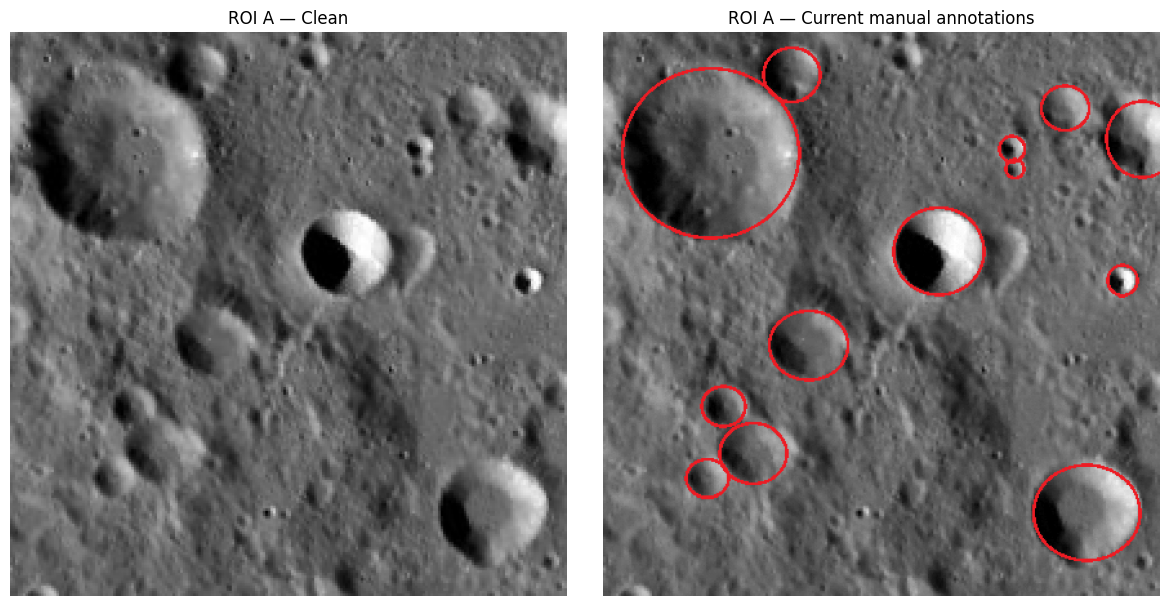

ROI size: (432, 438)


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

clean = Image.open("Benchmark 01.png").convert("RGB")
manual = Image.open("Benchmark_01_manual_aligned.png").convert("RGB")

# Región superior izquierda:
# left, top, right, bottom
roi_box = (0, 0, 432, 438)

clean_roi = clean.crop(roi_box)
manual_roi = manual.crop(roi_box)

clean_roi.save("Benchmark_01_ROI_A_clean.png")
manual_roi.save("Benchmark_01_ROI_A_manual.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(clean_roi)
axes[0].set_title("ROI A — Clean")
axes[0].axis("off")

axes[1].imshow(manual_roi)
axes[1].set_title("ROI A — Current manual annotations")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("ROI size:", clean_roi.size)

In [ ]:
!pip install -q ipympl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 88.5 MB/s eta 0:00:00


In [ ]:
from google.colab import output
output.enable_custom_widget_manager()

In [ ]:
from pathlib import Path
import pandas as pd
from google.colab import files

matches = list(
    Path("/content").rglob(
        "Benchmark_01_ROI_A_ground_truth.csv"
    )
)

if not matches:
    raise FileNotFoundError(
        "The ground-truth CSV was not found."
    )

ground_truth_path = matches[0]
ground_truth = pd.read_csv(ground_truth_path)

print("Ground-truth path:", ground_truth_path)
print("Number of craters:", len(ground_truth))
display(ground_truth)

files.download(str(ground_truth_path))

Ground-truth path: /content/MooCraDee/Benchmark_01_ROI_A_ground_truth.csv
Number of craters: 14


,gt_id,x_center,y_center,radius_px,include,confidence
0,1,78.77,90.35,73.34,True,high
1,2,143.59,30.52,19.05,True,high
2,3,234.33,18.56,9.19,True,high
3,4,259.25,171.12,31.53,True,high
4,5,315.09,89.35,9.97,True,high
5,6,317.09,106.31,4.46,True,high
6,7,354.98,60.44,16.60,True,high
7,8,399.85,193.06,10.79,True,high
8,9,155.55,239.93,24.14,True,high
9,10,94.73,289.78,13.56,True,high


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 9. Choose Pipeline Mode

PCS can run in two modes.

**Mode A: Large-image split pipeline**

Use this mode for the default Mercury image or for large planetary images. The image is divided into smaller parts, PCS runs detection on each part, and the results are combined into one CSV file.

**Mode B: Single-image detection without splitting**

Use this mode for smaller test images or uploaded planetary images. PCS runs directly on the selected image without dividing it into parts.

For a first test, use `single_image` mode. For the full Mercury workflow, use `split_image` mode.


In [ ]:
pipeline_mode = "single_image"  # Options: "single_image" or "split_image"

# Number of image parts for split_image mode.
# This must be a positive even number: 2, 4, 6, 8, ...
n_splits = 4

print("Selected pipeline mode:", pipeline_mode)

if pipeline_mode == "split_image":
    print("The image will be divided into", n_splits, "parts before detection.")
elif pipeline_mode == "single_image":
    print("PCS will run directly on the selected image without splitting.")
else:
    print("Invalid mode. Use 'single_image' or 'split_image'.")

Selected pipeline mode: single_image
PCS will run directly on the selected image without splitting.


# 10. Run PCS Pipeline

This section runs PCS using the selected image, detection parameters, and pipeline mode.

If `pipeline_mode = "single_image"`, PCS runs directly on the selected image and creates:

* an output image with detected crater candidates,
* a CSV file with candidate coordinates, radius, and score.

If `pipeline_mode = "split_image"`, PCS divides the selected image into multiple parts, runs detection on each part, and combines the detections into one CSV file.

This step may take several minutes depending on the image size, GPU availability, number of splits, and SAM parameters.



In [ ]:
from pathlib import Path

image_name = image_path.stem.replace(" ", "_").replace("(", "").replace(")", "")

if pipeline_mode == "single_image":
    output_image = Path(f"{image_name}_detected.png")
    output_csv = Path(f"{image_name}_craters.csv")

    print("Running PCS in single-image mode...")
    print("Input image:", image_path)

    !python -u deep_moocrade.py "{image_path}" \
      --ckpt sam_vit_b_01ec64.pth \
      --out "{output_image}" \
      --csv "{output_csv}" \
      --min_radius {min_radius} \
      --max_radius {max_radius} \
      --min_circularity {min_circularity} \
      --min_area {min_area} \
      --pps {points_per_side} \
      --pred_iou {pred_iou} \
      --stability {stability} \
      --iou_dedup {iou_dedup}

elif pipeline_mode == "split_image":
    output_dir = Path(f"{image_name}_split_{n_splits}")
    output_csv = output_dir / "all_craters.csv"

    print("Running PCS in split-image mode...")
    print("Input image:", image_path)
    print("Number of splits:", n_splits)

    !python -u run_pipeline.py \
      --image "{image_path}" \
      --splits {n_splits} \
      --checkpoint sam_vit_b_01ec64.pth \
      --output_dir "{output_dir}" \
      --min_radius {min_radius} \
      --max_radius {max_radius} \
      --min_circularity {min_circularity} \
      --min_area {min_area} \
      --points_per_side {points_per_side} \
      --pred_iou {pred_iou} \
      --stability {stability} \
      --iou_dedup {iou_dedup}

else:
    raise ValueError("Invalid pipeline_mode. Use 'single_image' or 'split_image'.")

Running PCS in single-image mode...
Input image: Benchmark 01.png
Using GPU/CUDA: Tesla T4
Device: cuda
Circulos finales: 43
1: centro=(375.1,371.6)  radio=42.8px  score=1.904
2: centro=(763.0,251.0)  radio=61.1px  score=1.903
3: centro=(113.0,484.5)  radio=20.7px  score=1.895
4: centro=(473.5,407.5)  radio=24.5px  score=1.876
5: centro=(87.6,96.6)  radio=77.8px  score=1.873
6: centro=(158.8,239.9)  radio=31.6px  score=1.862
7: centro=(243.5,175.0)  radio=27.4px  score=1.855
8: centro=(173.8,821.4)  radio=15.4px  score=1.839
9: centro=(82.9,345.0)  radio=18.4px  score=1.837
10: centro=(446.5,654.0)  radio=17.6px  score=1.831
11: centro=(262.5,424.0)  radio=15.0px  score=1.825
12: centro=(357.0,591.0)  radio=19.9px  score=1.825
13: centro=(323.5,554.5)  radio=15.2px  score=1.815
14: centro=(519.5,174.0)  radio=18.3px  score=1.813
15: centro=(96.7,290.9)  radio=17.7px  score=1.799
16: centro=(363.0,62.5)  radio=25.3px  score=1.795
17: centro=(583.0,75.5)  radio=34.4px  score=1.786
18: ce

# 11. Visualize Detection Results

This section displays the crater-candidate detection results.

In `single_image` mode, the notebook shows the detected output image created directly from the selected image.

In `split_image` mode, the notebook shows one detected image from the split-image workflow. You can change the part number to inspect a different section of the selected planetary image


In [ ]:
from IPython.display import Image, display
from pathlib import Path

if pipeline_mode == "single_image":
    if output_image.exists():
        print("Displaying:", output_image)
        display(Image(filename=str(output_image)))
    else:
        print("Output image not found:", output_image)

elif pipeline_mode == "split_image":
    part_number = 1  # Change this number to view another part
    split_output_image = Path(f"{image_path.stem}_split_{n_splits}") / f"part_{part_number}" / "detected.png"

    if split_output_image.exists():
        print("Displaying:", split_output_image)
        display(Image(filename=str(split_output_image)))
    else:
        print("Output image not found:", split_output_image)

NameError: name 'pipeline_mode' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# 12. Load Crater Candidate CSV

PCS saves the detected crater candidates into a CSV file.

In `single_image` mode, the CSV contains the candidate ID, center coordinates, radius in pixels, and score for the selected image.

In `split_image` mode, PCS combines the detections from all image parts into one CSV file. This combined file includes both local coordinates within each split image and global coordinates relative to the original image.

This CSV is the beginning of a crater-candidate database that can be inspected, filtered, exported, or used for later analysis.


In [ ]:
import pandas as pd
from pathlib import Path

if output_csv.exists():
    df = pd.read_csv(output_csv)
    print("Loaded CSV:", output_csv)
    print("Number of crater candidates:", len(df))
    display(df.head())
else:
    print("CSV file not found:", output_csv)

NameError: name 'output_csv' is not defined

# 13. Candidate Output Summary

This section gives a quick summary of the crater-candidate output.

The goal here is not to make a final scientific conclusion. Instead, this step helps check whether the pipeline produced a usable set of candidates by showing:

* the total number of crater candidates,
* the radius range in pixels,
* the average candidate size,
* and a simple radius distribution plot.

This summary helps users understand how the selected parameters affected the detection results.


Total crater candidates: 229
Minimum radius: 10.0
Maximum radius: 78.89
Average radius: 17.6453711790393


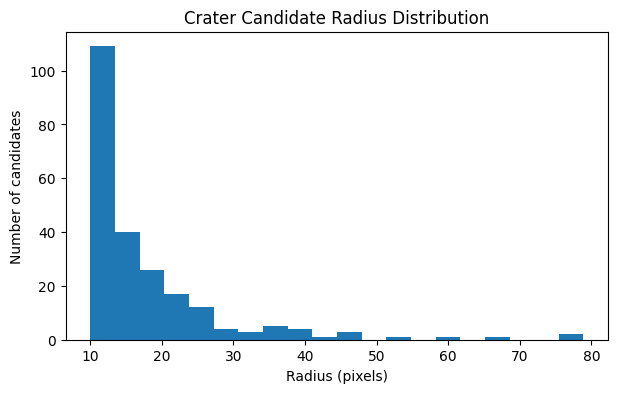

In [ ]:
import matplotlib.pyplot as plt

if "df" in globals() and not df.empty:
    print("Total crater candidates:", len(df))

    if "radius_px" in df.columns:
        print("Minimum radius:", df["radius_px"].min())
        print("Maximum radius:", df["radius_px"].max())
        print("Average radius:", df["radius_px"].mean())

        plt.figure(figsize=(7, 4))
        plt.hist(df["radius_px"], bins=20)
        plt.xlabel("Radius (pixels)")
        plt.ylabel("Number of candidates")
        plt.title("Crater Candidate Radius Distribution")
        plt.show()
    else:
        print("The CSV does not contain a 'radius_px' column.")
else:
    print("No crater-candidate data loaded yet.")

In [ ]:
import json
import subprocess
from datetime import datetime, timezone
from pathlib import Path

run_metadata = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "input_image": str(image_path),
    "pipeline_mode": pipeline_mode,
    "number_of_splits": n_splits if pipeline_mode == "split_image" else None,
    "parameters": {
        "min_radius": min_radius,
        "max_radius": max_radius,
        "min_circularity": min_circularity,
        "min_area": min_area,
        "points_per_side": points_per_side,
        "pred_iou": pred_iou,
        "stability": stability,
        "iou_dedup": iou_dedup,
    },
    "candidate_count": len(df),
    "git_commit": subprocess.check_output(
        ["git", "rev-parse", "HEAD"],
        text=True
    ).strip(),
    "gpu": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else None
    ),
}

metadata_path = Path(f"{image_name}_run_metadata.json")

with open(metadata_path, "w", encoding="utf-8") as file:
    json.dump(run_metadata, file, indent=2)

print("Saved run metadata:", metadata_path)

Saved run metadata: test1.1_moon_run_metadata.json


# 14. Export Results

Google Colab stores files in a temporary runtime. If the runtime disconnects or restarts, the generated outputs may be deleted.

This section lets you save the PCS results by copying them to Google Drive.

The exported results may include:

* the detected output image,
* the crater-candidate CSV file,
* and, in split-image mode, the full output folder with all image parts.


In [ ]:
from google.colab import drive
from pathlib import Path
import shutil

drive.mount("/content/drive")

export_dir = Path("/content/drive/MyDrive/PCS_outputs")
export_dir.mkdir(parents=True, exist_ok=True)

print("Export folder:", export_dir)

if pipeline_mode == "single_image":
    files_to_export = [output_image, output_csv]

    for file in files_to_export:
        file = Path(file)
        if file.exists():
            shutil.copy(file, export_dir / file.name)
            print("Exported:", file.name)
        else:
            print("Missing:", file)

elif pipeline_mode == "split_image":
    split_dir = Path(f"{image_path.stem}_split_{n_splits}")

    if split_dir.exists():
        destination = export_dir / split_dir.name
        shutil.copytree(split_dir, destination, dirs_exist_ok=True)
        print("Exported folder:", destination)
    else:
        print("Split output folder not found:", split_dir)

print("Export complete.")

Mounted at /content/drive
Export folder: /content/drive/MyDrive/PCS_outputs


NameError: name 'pipeline_mode' is not defined

# 15. Future Work

This notebook is an initial reproducible workflow for running PCS in Google Colab.

At this stage, the main goal is to make the pipeline easier to run, test, modify, and extend. Future development may include:

* adding interactive sliders for detection parameters,
* improving support for uploaded planetary images,
* saving experiment metadata with each run,
* comparing PCS outputs across different parameter settings,
* adding side-by-side visual comparisons of input and detected images,
* converting pixel measurements into physical units when image scale is available,
* organizing outputs into a larger crater-candidate database,
* and comparing future PCS results with trusted crater catalogs or expert-reviewed data.

This notebook is intended to support continued experimentation with AI-assisted planetary surface analysis.


# 15. Phase 2 — Detection Evaluation

In [ ]:
from google.colab import files

uploaded_csv = files.upload()

print("Uploaded CSV files:")
for filename in uploaded_csv:
    print("-", filename)

Saving Benchmark_01_craters.csv to Benchmark_01_craters.csv
Saving Benchmark_01_craters_run2.csv to Benchmark_01_craters_run2.csv
Saving Benchmark_01_craters_run3.csv to Benchmark_01_craters_run3.csv
Uploaded CSV files:
- Benchmark_01_craters.csv
- Benchmark_01_craters_run2.csv
- Benchmark_01_craters_run3.csv


In [ ]:
from pathlib import Path
from PIL import Image

# Exact clean image used by PCS
FULL_IMAGE_PATH = Path("Benchmark 01.png")

if not FULL_IMAGE_PATH.exists():
    raise FileNotFoundError(
        f"Image not found: {FULL_IMAGE_PATH}"
    )

full_image = Image.open(FULL_IMAGE_PATH).convert("RGB")

image_width, image_height = full_image.size

middle_x = image_width // 2
middle_y = image_height // 2

# Coordinates follow:
# left, top, right, bottom
ROIS = {
    "A": (0, 0, middle_x, middle_y),
    "B": (middle_x, 0, image_width, middle_y),
    "C": (0, middle_y, middle_x, image_height),
    "D": (middle_x, middle_y, image_width, image_height),
}

print("Complete image size:", full_image.size)

for roi_name, roi_box in ROIS.items():
    roi_image = full_image.crop(roi_box)

    roi_image_path = Path(
        f"Benchmark_01_ROI_{roi_name}_clean.png"
    )

    roi_image.save(roi_image_path)

    print(
        f"ROI {roi_name}:",
        f"box={roi_box},",
        f"size={roi_image.size},",
        f"saved={roi_image_path}"
    )

Complete image size: (865, 877)
ROI A: box=(0, 0, 432, 438), size=(432, 438), saved=Benchmark_01_ROI_A_clean.png
ROI B: box=(432, 0, 865, 438), size=(433, 438), saved=Benchmark_01_ROI_B_clean.png
ROI C: box=(0, 438, 432, 877), size=(432, 439), saved=Benchmark_01_ROI_C_clean.png
ROI D: box=(432, 438, 865, 877), size=(433, 439), saved=Benchmark_01_ROI_D_clean.png


In [ ]:
from pathlib import Path

# Change only this letter:
ROI_NAME = "D"

if ROI_NAME not in ROIS:
    raise ValueError(
        "ROI_NAME must be A, B, C, or D."
    )

left, top, right, bottom = ROIS[ROI_NAME]

image_path = Path(
    f"Benchmark_01_ROI_{ROI_NAME}_clean.png"
)

csv_path = Path(
    f"Benchmark_01_ROI_{ROI_NAME}_ground_truth.csv"
)

callback_name = (
    f"pcs.save_ground_truth_{ROI_NAME}"
)

if not image_path.exists():
    raise FileNotFoundError(
        f"ROI image not found: {image_path}"
    )

print("Selected ROI:", ROI_NAME)
print("ROI image:", image_path)
print("Output CSV:", csv_path)
print("Global offset:", (left, top))
print("ROI dimensions:", (right - left, bottom - top))

Selected ROI: D
ROI image: Benchmark_01_ROI_D_clean.png
Output CSV: Benchmark_01_ROI_D_ground_truth.csv
Global offset: (432, 438)
ROI dimensions: (433, 439)


In [ ]:
import base64
import json
import pandas as pd

from google.colab import output


def save_ground_truth(annotation_json):
    """
    Receive local crater annotations from the browser,
    convert them to full-image coordinates, and save them as CSV.
    """

    annotations = json.loads(annotation_json)

    ground_truth = pd.DataFrame(annotations)

    if ground_truth.empty:
        raise ValueError(
            "No crater annotations were received."
        )

    required_columns = {
        "x_center",
        "y_center",
        "radius_px",
    }

    missing_columns = (
        required_columns - set(ground_truth.columns)
    )

    if missing_columns:
        raise ValueError(
            "Missing annotation columns: "
            f"{sorted(missing_columns)}"
        )

    # Preserve coordinates relative to the current quarter.
    ground_truth = ground_truth.rename(
        columns={
            "x_center": "x_local",
            "y_center": "y_local",
        }
    )

    # Convert local ROI coordinates to full-image coordinates.
    ground_truth["x_center"] = (
        ground_truth["x_local"] + left
    )

    ground_truth["y_center"] = (
        ground_truth["y_local"] + top
    )

    ground_truth.insert(
        0,
        "roi_gt_id",
        range(1, len(ground_truth) + 1),
    )

    ground_truth.insert(
        0,
        "roi",
        ROI_NAME,
    )

    ground_truth["include"] = True
    ground_truth["confidence"] = "high"

    columns = [
        "roi",
        "roi_gt_id",
        "x_local",
        "y_local",
        "x_center",
        "y_center",
        "radius_px",
        "include",
        "confidence",
    ]

    ground_truth = ground_truth[columns]

    ground_truth.to_csv(
        csv_path,
        index=False,
    )

    print(f"Saved: {csv_path}")
    print(
        f"Ground-truth craters in ROI {ROI_NAME}:",
        len(ground_truth),
    )

    return {
        "saved": True,
        "count": len(ground_truth),
        "path": str(csv_path),
    }


output.register_callback(
    callback_name,
    save_ground_truth,
)

image_base64 = base64.b64encode(
    image_path.read_bytes()
).decode("utf-8")

print(
    f"Annotation callback registered for ROI {ROI_NAME}."
)

Annotation callback registered for ROI D.



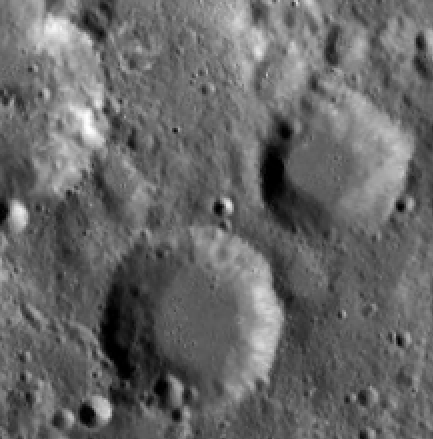

Saved: Benchmark_01_ROI_D_ground_truth.csv
Ground-truth craters in ROI D: 10


In [ ]:
from IPython.display import HTML, display

canvas_id = f"pcsCanvas_{ROI_NAME}"
undo_id = f"undoButton_{ROI_NAME}"
cancel_id = f"cancelButton_{ROI_NAME}"
save_id = f"saveButton_{ROI_NAME}"
status_id = f"statusText_{ROI_NAME}"

annotation_tool = f"""
<div style="
    font-family: Arial, sans-serif;
    max-width: 760px;
    padding: 16px;
    border: 1px solid #cccccc;
    border-radius: 10px;
">

  <h3>PCS Ground Truth Annotation — ROI {ROI_NAME}</h3>

  <p>
    <b>Click 1:</b> crater center<br>
    <b>Click 2:</b> crater edge
  </p>

  <canvas
    id="{canvas_id}"
    style="
        border: 1px solid #888888;
        cursor: crosshair;
        max-width: 100%;
    ">
  </canvas>

  <br><br>

  <button id="{undo_id}">
    Undo last crater
  </button>

  <button id="{cancel_id}">
    Cancel pending center
  </button>

  <button id="{save_id}">
    Save ROI {ROI_NAME} ground truth
  </button>

  <p id="{status_id}">
    <b>Waiting for the first crater center.</b>
  </p>
</div>

<script>
(() => {{
  const canvas = document.getElementById("{canvas_id}");
  const context = canvas.getContext("2d");
  const status = document.getElementById("{status_id}");

  const image = new Image();

  let annotations = [];
  let pendingCenter = null;

  image.src = "data:image/png;base64,{image_base64}";

  image.onload = () => {{
    canvas.width = image.naturalWidth;
    canvas.height = image.naturalHeight;
    redraw();
  }};

  function redraw() {{
    context.clearRect(
      0,
      0,
      canvas.width,
      canvas.height
    );

    context.drawImage(image, 0, 0);

    annotations.forEach((crater, index) => {{
      context.beginPath();

      context.arc(
        crater.x_center,
        crater.y_center,
        crater.radius_px,
        0,
        2 * Math.PI
      );

      context.strokeStyle = "red";
      context.lineWidth = 2;
      context.stroke();

      context.fillStyle = "yellow";
      context.font = "13px Arial";

      context.fillText(
        String(index + 1),
        crater.x_center + 4,
        crater.y_center - 4
      );
    }});

    if (pendingCenter !== null) {{
      context.beginPath();

      context.arc(
        pendingCenter.x,
        pendingCenter.y,
        4,
        0,
        2 * Math.PI
      );

      context.fillStyle = "cyan";
      context.fill();
    }}
  }}

  function getImageCoordinates(event) {{
    const rectangle = canvas.getBoundingClientRect();

    const scaleX =
      canvas.width / rectangle.width;

    const scaleY =
      canvas.height / rectangle.height;

    return {{
      x:
        (event.clientX - rectangle.left)
        * scaleX,

      y:
        (event.clientY - rectangle.top)
        * scaleY
    }};
  }}

  canvas.addEventListener("click", event => {{
    const point = getImageCoordinates(event);

    if (pendingCenter === null) {{
      pendingCenter = point;

      status.innerHTML =
        `<b>Center selected:</b> ` +
        `(${{point.x.toFixed(1)}}, ` +
        `${{point.y.toFixed(1)}}). ` +
        `Now click the crater edge.`;

      redraw();
      return;
    }}

    const radius = Math.hypot(
      point.x - pendingCenter.x,
      point.y - pendingCenter.y
    );

    annotations.push({{
      x_center:
        Number(pendingCenter.x.toFixed(2)),

      y_center:
        Number(pendingCenter.y.toFixed(2)),

      radius_px:
        Number(radius.toFixed(2))
    }});

    pendingCenter = null;

    status.innerHTML =
      `<b>Crater ${{annotations.length}} saved.</b> ` +
      `Click the next crater center.`;

    redraw();
  }});

  document
    .getElementById("{undo_id}")
    .onclick = () => {{

      if (pendingCenter !== null) {{
        pendingCenter = null;

        status.innerHTML =
          "<b>Pending center cancelled.</b>";

        redraw();
        return;
      }}

      if (annotations.length > 0) {{
        annotations.pop();

        status.innerHTML =
          `<b>Last crater removed.</b> ` +
          `${{annotations.length}} annotations remain.`;

        redraw();
      }}
    }};

  document
    .getElementById("{cancel_id}")
    .onclick = () => {{

      pendingCenter = null;

      status.innerHTML =
        "<b>Pending center cancelled.</b>";

      redraw();
    }};

  document
    .getElementById("{save_id}")
    .onclick = async () => {{

      if (annotations.length === 0) {{
        status.innerHTML =
          "<b>No annotations to save.</b>";

        return;
      }}

      await google.colab.kernel.invokeFunction(
        "{callback_name}",
        [JSON.stringify(annotations)],
        {{}}
      );

      status.innerHTML =
        `<b>Saved ${{annotations.length}} craters.</b><br>` +
        `File: {csv_path.name}`;
    }};
}})();
</script>
"""

display(HTML(annotation_tool))

In [ ]:
from google.colab import files
import pandas as pd

if not csv_path.exists():
    raise FileNotFoundError(
        f"Ground-truth CSV not found: {csv_path}"
    )

roi_ground_truth = pd.read_csv(csv_path)

print("ROI:", ROI_NAME)
print("Ground-truth file:", csv_path)
print(
    "Annotated craters:",
    len(roi_ground_truth),
)

display(roi_ground_truth)

# Download immediately so it is not lost
files.download(str(csv_path))

ROI: D
Ground-truth file: Benchmark_01_ROI_D_ground_truth.csv
Annotated craters: 10


,roi,roi_gt_id,x_local,y_local,x_center,y_center,radius_px,include,confidence
0,D,1,11.35,214.38,443.35,652.38,17.07,True,high
1,D,2,3.37,94.72,435.37,532.72,100.89,True,high
2,D,3,187.84,319.08,619.84,757.08,91.50,True,high
3,D,4,95.10,410.82,527.10,848.82,15.95,True,high
4,D,5,64.19,418.80,496.19,856.80,10.02,True,high
5,D,6,222.74,207.40,654.74,645.40,9.03,True,high
6,D,7,331.42,170.51,763.42,608.51,73.96,True,high
7,D,8,403.22,202.41,835.22,640.41,9.19,True,high
8,D,9,367.32,395.87,799.32,833.87,9.19,True,high
9,D,10,344.39,46.86,776.39,484.86,23.70,True,high


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from pathlib import Path
import pandas as pd

ground_truth_parts = []

for roi_name in ["A", "B", "C", "D"]:
    roi_csv_path = Path(
        f"Benchmark_01_ROI_{roi_name}_ground_truth.csv"
    )

    if not roi_csv_path.exists():
        raise FileNotFoundError(
            f"Missing ground-truth file: "
            f"{roi_csv_path}"
        )

    roi_ground_truth = pd.read_csv(
        roi_csv_path
    )

    ground_truth_parts.append(
        roi_ground_truth
    )

full_ground_truth = pd.concat(
    ground_truth_parts,
    ignore_index=True,
)

full_ground_truth.insert(
    0,
    "gt_id",
    range(
        1,
        len(full_ground_truth) + 1,
    ),
)

full_ground_truth_path = Path(
    "Benchmark_01_full_ground_truth.csv"
)

full_ground_truth.to_csv(
    full_ground_truth_path,
    index=False,
)

print("Full-image ground truth created.")
print(
    "Total annotated craters:",
    len(full_ground_truth),
)
print("Saved:", full_ground_truth_path)

display(full_ground_truth)

Full-image ground truth created.
Total annotated craters: 51
Saved: Benchmark_01_full_ground_truth.csv


,gt_id,roi,roi_gt_id,x_local,y_local,x_center,y_center,radius_px,include,confidence
0,1,A,1,142.97,29.90,142.97,29.90,24.34,True,high
1,2,A,2,86.13,93.72,86.13,93.72,73.57,True,high
2,3,A,3,260.63,172.50,260.63,172.50,33.43,True,high
3,4,A,4,157.92,242.30,157.92,242.30,26.83,True,high
4,5,A,5,97.10,290.16,97.10,290.16,16.08,True,high
5,6,A,6,118.04,324.06,118.04,324.06,28.22,True,high
6,7,A,7,81.15,344.01,81.15,344.01,17.98,True,high
7,8,A,8,372.31,370.93,372.31,370.93,39.90,True,high
8,9,A,9,310.49,172.50,310.49,172.50,20.56,True,high
9,10,A,10,401.23,194.43,401.23,194.43,11.28,True,high


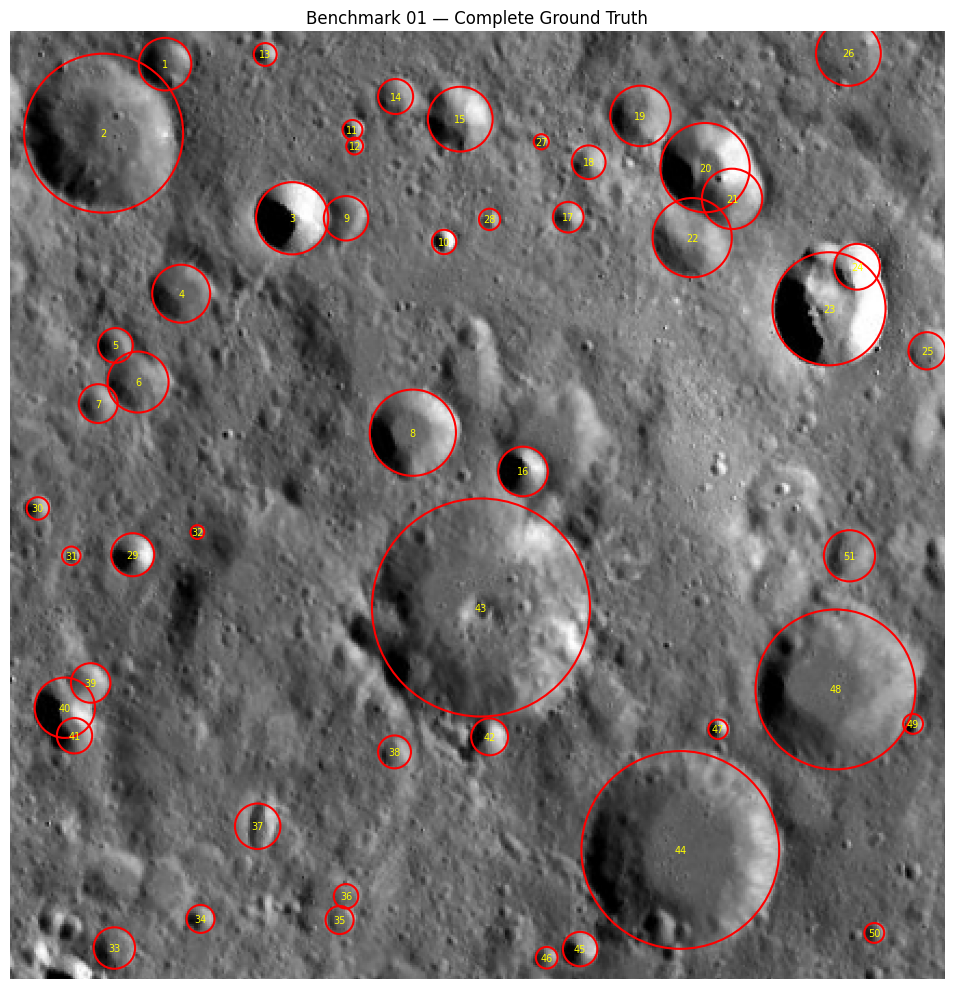

Preview saved: Benchmark_01_full_ground_truth_preview.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(
    figsize=(10, 10)
)

ax.imshow(full_image)

for crater in full_ground_truth.itertuples():
    circle = patches.Circle(
        (
            crater.x_center,
            crater.y_center,
        ),
        crater.radius_px,
        fill=False,
        edgecolor="red",
        linewidth=1.5,
    )

    ax.add_patch(circle)

    ax.text(
        crater.x_center,
        crater.y_center,
        str(crater.gt_id),
        color="yellow",
        fontsize=7,
        ha="center",
        va="center",
    )

ax.set_title(
    "Benchmark 01 — Complete Ground Truth"
)

ax.axis("off")

plt.tight_layout()

preview_path = Path(
    "Benchmark_01_full_ground_truth_preview.png"
)

plt.savefig(
    preview_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Preview saved:", preview_path)

In [ ]:
from pathlib import Path
from google.colab import files
import pandas as pd

ground_truth_path = Path(
    "Benchmark_01_full_ground_truth.csv"
)

ground_truth = pd.read_csv(ground_truth_path)

# Common eligibility rule for comparison across B1, B2 and B3
ground_truth["include"] = (
    ground_truth["radius_px"] >= 9
)

evaluation_path = Path(
    "Benchmark_01_full_ground_truth_evaluation.csv"
)

ground_truth.to_csv(
    evaluation_path,
    index=False
)

print("Total annotations:", len(ground_truth))
print(
    "Included in evaluation:",
    int(ground_truth["include"].sum())
)
print(
    "Excluded because radius < 9 px:",
    int((~ground_truth["include"]).sum())
)

files.download(str(evaluation_path))

Total annotations: 51
Included in evaluation: 47
Excluded because radius < 9 px: 4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from pathlib import Path
import pandas as pd

files_to_check = {
    "Ground truth": "Benchmark_01_full_ground_truth.csv",
    "Run B1": "Benchmark_01_craters.csv",
    "Run B2": "Benchmark_01_craters_run2.csv",
    "Run B3": "Benchmark_01_craters_run3.csv",
}

loaded_data = {}

for name, filename in files_to_check.items():
    path = Path(filename)

    if not path.exists():
        print(f"Missing: {filename}")
        continue

    df = pd.read_csv(path)
    loaded_data[name] = df

    print(f" {name}")
    print(f"   File: {filename}")
    print(f"   Rows: {len(df)}")
    print(f"   Columns: {list(df.columns)}")
    print()

# Ground-truth summary
if "Ground truth" in loaded_data:
    ground_truth = loaded_data["Ground truth"]

    eligible_ground_truth = ground_truth[
        (ground_truth["include"] == True)
        & (ground_truth["radius_px"] >= 9)
    ].copy()

    print("GROUND-TRUTH SUMMARY")
    print("Total manually annotated craters:", len(ground_truth))
    print(
        "Eligible craters with radius >= 9 px:",
        len(eligible_ground_truth)
    )
    print(
        "Excluded only from evaluation because radius < 9 px:",
        len(ground_truth) - len(eligible_ground_truth)
    )

 Ground truth
   File: Benchmark_01_full_ground_truth.csv
   Rows: 51
   Columns: ['gt_id', 'roi', 'roi_gt_id', 'x_local', 'y_local', 'x_center', 'y_center', 'radius_px', 'include', 'confidence']

 Run B1
   File: Benchmark_01_craters.csv
   Rows: 101
   Columns: ['id', 'x_px', 'y_px', 'radius_px', 'score']

 Run B2
   File: Benchmark_01_craters_run2.csv
   Rows: 113
   Columns: ['id', 'x_px', 'y_px', 'radius_px', 'score']

 Run B3
   File: Benchmark_01_craters_run3.csv
   Rows: 120
   Columns: ['id', 'x_px', 'y_px', 'radius_px', 'score']

GROUND-TRUTH SUMMARY
Total manually annotated craters: 51
Eligible craters with radius >= 9 px: 47
Excluded only from evaluation because radius < 9 px: 4


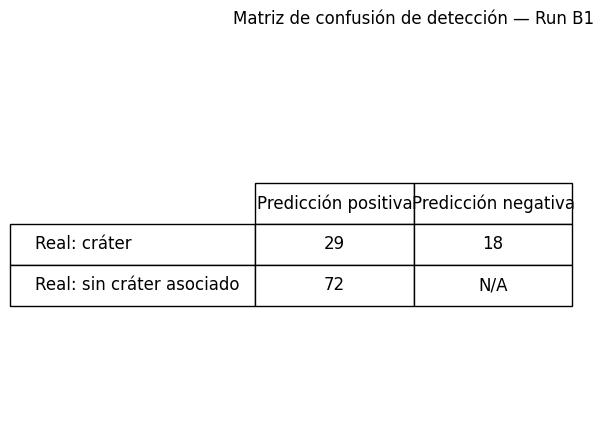

Guardado: Benchmark_01_confusion_matrix_B1.png


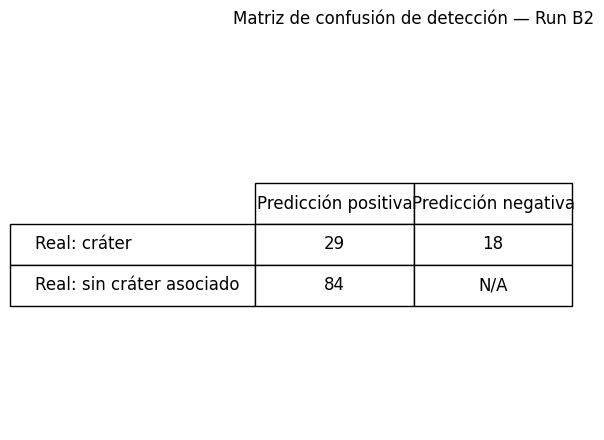

Guardado: Benchmark_01_confusion_matrix_B2.png


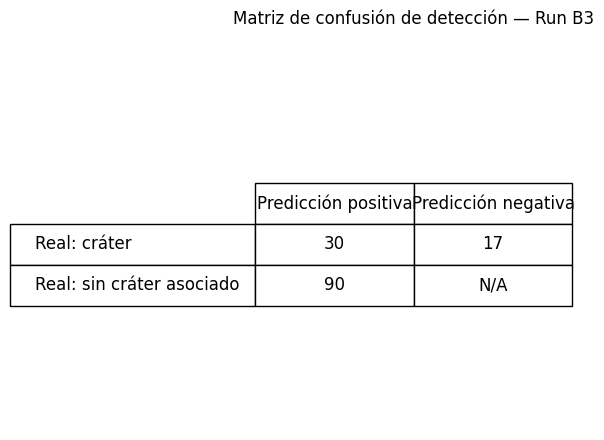

Guardado: Benchmark_01_confusion_matrix_B3.png


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Verificar que la tabla de resultados exista
if "metrics_df" not in globals():
    raise NameError(
        "Primero ejecuta la celda de evaluación que crea metrics_df."
    )

for _, row in metrics_df.iterrows():

    run_name = row["Run"]

    matrix_text = [
        [str(int(row["TP"])), str(int(row["FN"]))],
        [str(int(row["FP"])), "N/A"]
    ]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.axis("off")

    table = ax.table(
        cellText=matrix_text,
        rowLabels=[
            "Real: cráter",
            "Real: sin cráter asociado"
        ],
        colLabels=[
            "Predicción positiva",
            "Predicción negativa"
        ],
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.35, 2.3)

    ax.set_title(
        f"Matriz de confusión de detección — Run {run_name}",
        pad=25
    )

    plt.tight_layout()

    output_path = (
        f"Benchmark_01_confusion_matrix_{run_name}.png"
    )

    plt.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    print("Guardado:", output_path)

Eligible ground-truth craters: 47

PCS EVALUATION RESULTS


,Run,Predictions,TP,FP,FN,TN,Precision,Recall,F1
0,B1,101,29,72,18,N/A,0.2871,0.6170,0.3919
1,B2,113,29,84,18,N/A,0.2566,0.6170,0.3625
2,B3,120,30,90,17,N/A,0.2500,0.6383,0.3593


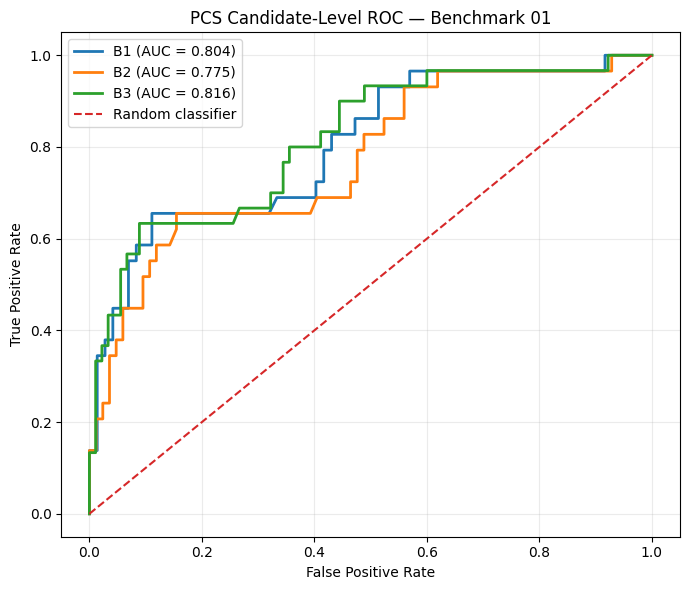


ROC RESULTS


,Run,ROC_AUC
0,B1,0.8039
1,B2,0.7746
2,B3,0.8165



Saved files:
- Benchmark_01_final_metrics.csv
- Benchmark_01_ROC_results.csv
- Benchmark_01_ROC.png
- Benchmark_01_B1_evaluated.csv
- Benchmark_01_B2_evaluated.csv
- Benchmark_01_B3_evaluated.csv


In [ ]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.metrics import roc_auc_score, roc_curve


# =========================================================
# 1. Load ground truth and predictions
# =========================================================

ground_truth = pd.read_csv(
    "Benchmark_01_full_ground_truth.csv"
)

runs = {
    "B1": pd.read_csv("Benchmark_01_craters.csv"),
    "B2": pd.read_csv("Benchmark_01_craters_run2.csv"),
    "B3": pd.read_csv("Benchmark_01_craters_run3.csv"),
}


# Use the same minimum detectable radius for all three runs.
eligible_ground_truth = ground_truth[
    (ground_truth["include"] == True)
    & (ground_truth["radius_px"] >= 9)
].copy().reset_index(drop=True)

print(
    "Eligible ground-truth craters:",
    len(eligible_ground_truth)
)


# =========================================================
# 2. Fixed matching rule
# =========================================================
#
# A prediction matches a manually annotated crater when:
#
# 1. Center distance <= 50% of the ground-truth radius
# 2. Predicted radius is between 50% and 150% of
#    the ground-truth radius
# 3. Each crater and prediction can be matched only once
#
# Additional detections are counted as false positives.
# =========================================================

CENTER_DISTANCE_FACTOR = 0.50
MIN_RADIUS_RATIO = 0.50
MAX_RADIUS_RATIO = 1.50


def evaluate_run(
    ground_truth_df,
    predictions_df,
):
    gt = ground_truth_df.reset_index(drop=True)
    predictions = predictions_df.reset_index(drop=True).copy()

    possible_matches = []

    for gt_index, gt_row in gt.iterrows():
        for pred_index, pred_row in predictions.iterrows():

            center_distance = math.hypot(
                pred_row["x_px"] - gt_row["x_center"],
                pred_row["y_px"] - gt_row["y_center"],
            )

            radius_ratio = (
                pred_row["radius_px"]
                / gt_row["radius_px"]
            )

            center_matches = (
                center_distance
                <= CENTER_DISTANCE_FACTOR
                * gt_row["radius_px"]
            )

            radius_matches = (
                MIN_RADIUS_RATIO
                <= radius_ratio
                <= MAX_RADIUS_RATIO
            )

            if center_matches and radius_matches:

                normalized_distance = (
                    center_distance
                    / gt_row["radius_px"]
                )

                radius_error = abs(
                    math.log(radius_ratio)
                )

                geometric_cost = (
                    normalized_distance
                    + radius_error
                )

                possible_matches.append(
                    {
                        "gt_index": gt_index,
                        "pred_index": pred_index,
                        "distance_px": center_distance,
                        "radius_ratio": radius_ratio,
                        "cost": geometric_cost,
                    }
                )

    # Best geometric matches are assigned first.
    possible_matches.sort(
        key=lambda match: match["cost"]
    )

    matched_gt = set()
    matched_predictions = set()
    final_matches = []

    for match in possible_matches:

        gt_index = match["gt_index"]
        pred_index = match["pred_index"]

        if (
            gt_index not in matched_gt
            and pred_index not in matched_predictions
        ):
            matched_gt.add(gt_index)
            matched_predictions.add(pred_index)
            final_matches.append(match)

    # Label every prediction.
    predictions["evaluation"] = "FP"
    predictions["matched_gt_id"] = pd.NA
    predictions["center_distance_px"] = np.nan
    predictions["radius_ratio"] = np.nan

    for match in final_matches:

        gt_index = match["gt_index"]
        pred_index = match["pred_index"]

        predictions.loc[
            pred_index,
            "evaluation"
        ] = "TP"

        predictions.loc[
            pred_index,
            "matched_gt_id"
        ] = gt.loc[gt_index, "gt_id"]

        predictions.loc[
            pred_index,
            "center_distance_px"
        ] = match["distance_px"]

        predictions.loc[
            pred_index,
            "radius_ratio"
        ] = match["radius_ratio"]

    tp = len(final_matches)
    fp = len(predictions) - tp
    fn = len(gt) - tp

    precision = (
        tp / (tp + fp)
        if tp + fp > 0
        else 0
    )

    recall = (
        tp / (tp + fn)
        if tp + fn > 0
        else 0
    )

    f1 = (
        2 * precision * recall
        / (precision + recall)
        if precision + recall > 0
        else 0
    )

    metrics = {
        "Predictions": len(predictions),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": "N/A",
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
    }

    return metrics, predictions


# =========================================================
# 3. Evaluate B1, B2 and B3
# =========================================================

results = []
evaluated_runs = {}

for run_name, predictions in runs.items():

    metrics, evaluated_predictions = evaluate_run(
        eligible_ground_truth,
        predictions,
    )

    metrics["Run"] = run_name
    results.append(metrics)

    evaluated_runs[run_name] = (
        evaluated_predictions
    )

    evaluated_predictions.to_csv(
        f"Benchmark_01_{run_name}_evaluated.csv",
        index=False,
    )


metrics_df = pd.DataFrame(results)

metrics_df = metrics_df[
    [
        "Run",
        "Predictions",
        "TP",
        "FP",
        "FN",
        "TN",
        "Precision",
        "Recall",
        "F1",
    ]
]

for column in ["Precision", "Recall", "F1"]:
    metrics_df[column] = (
        metrics_df[column].round(4)
    )

print("\nPCS EVALUATION RESULTS")
display(metrics_df)

metrics_df.to_csv(
    "Benchmark_01_final_metrics.csv",
    index=False,
)


# =========================================================
# 4. Candidate-level ROC
# =========================================================
#
# Positive candidate = matched prediction (TP)
# Negative candidate = unmatched prediction (FP)
#
# This ROC evaluates how well the PCS score separates
# valid detections from false detections.
# =========================================================

plt.figure(figsize=(7, 6))

roc_results = []

for run_name, evaluated_predictions in (
    evaluated_runs.items()
):

    true_labels = (
        evaluated_predictions["evaluation"] == "TP"
    ).astype(int)

    detection_scores = (
        evaluated_predictions["score"].astype(float)
    )

    fpr, tpr, thresholds = roc_curve(
        true_labels,
        detection_scores,
    )

    auc_value = roc_auc_score(
        true_labels,
        detection_scores,
    )

    roc_results.append(
        {
            "Run": run_name,
            "ROC_AUC": auc_value,
        }
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{run_name} (AUC = {auc_value:.3f})",
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    "PCS Candidate-Level ROC — Benchmark 01"
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    "Benchmark_01_ROC.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


roc_df = pd.DataFrame(roc_results)
roc_df["ROC_AUC"] = roc_df["ROC_AUC"].round(4)

print("\nROC RESULTS")
display(roc_df)

roc_df.to_csv(
    "Benchmark_01_ROC_results.csv",
    index=False,
)


print("\nSaved files:")
print("- Benchmark_01_final_metrics.csv")
print("- Benchmark_01_ROC_results.csv")
print("- Benchmark_01_ROC.png")
print("- Benchmark_01_B1_evaluated.csv")
print("- Benchmark_01_B2_evaluated.csv")
print("- Benchmark_01_B3_evaluated.csv")